<a href="https://colab.research.google.com/github/krishikasahni/Deep-Learning/blob/main/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AE Epoch 1: Loss = 266.1027
AE Epoch 2: Loss = 232.1350
AE Epoch 3: Loss = 227.0706
AE Epoch 4: Loss = 224.1663
AE Epoch 5: Loss = 222.2922
AE Epoch 6: Loss = 220.9393
AE Epoch 7: Loss = 219.9419
AE Epoch 8: Loss = 219.1326
AE Epoch 9: Loss = 218.4961
AE Epoch 10: Loss = 218.0094
VAE Epoch 1: Loss = 296.8152
VAE Epoch 2: Loss = 260.2367
VAE Epoch 3: Loss = 254.0855
VAE Epoch 4: Loss = 250.9015
VAE Epoch 5: Loss = 248.8128
VAE Epoch 6: Loss = 247.4727
VAE Epoch 7: Loss = 246.5092
VAE Epoch 8: Loss = 245.7705
VAE Epoch 9: Loss = 245.2276
VAE Epoch 10: Loss = 244.7301

Autoencoder Results:


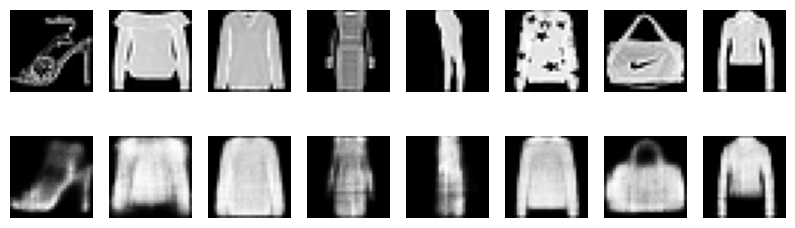


VAE Results:


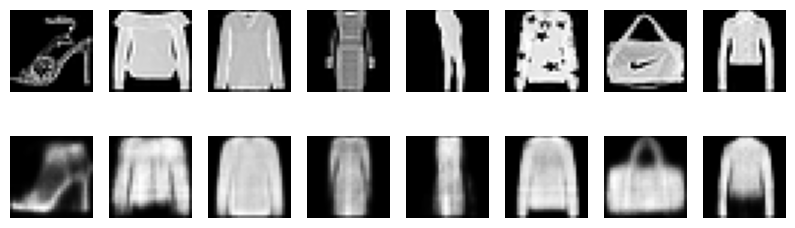


Generated Images (VAE):


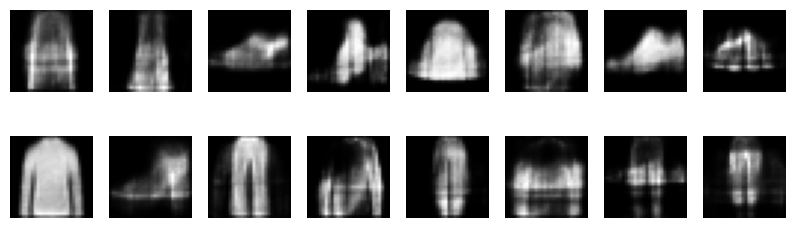

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
latent_dim = 16
epochs = 10
lr = 1e-3

transform = transforms.ToTensor()
dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

#AUTOENCODER
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 784)
        z = self.encoder(x)
        out = self.decoder(z)
        return out

#VAE
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
        self.fc2 = nn.Linear(latent_dim, 256)
        self.fc3 = nn.Linear(256, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        x = x.view(-1, 784)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

#LOSS FUNCTIONS
bce_loss = nn.BCELoss(reduction='sum')

def vae_loss(recon, x, mu, logvar):
    recon_loss = bce_loss(recon, x.view(-1, 784))
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl

def train_autoencoder(model, optimizer):
    model.train()
    total_loss = 0

    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()

        recon = model(x)
        loss = bce_loss(recon, x.view(-1, 784))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader.dataset)

def train_vae(model, optimizer):
    model.train()
    total_loss = 0

    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()

        recon, mu, logvar = model(x)
        loss = vae_loss(recon, x, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader.dataset)

ae = Autoencoder(latent_dim).to(device)
vae = VAE(latent_dim).to(device)

opt_ae = optim.Adam(ae.parameters(), lr=lr)
opt_vae = optim.Adam(vae.parameters(), lr=lr)

for epoch in range(epochs):
    loss = train_autoencoder(ae, opt_ae)
    print(f"AE Epoch {epoch+1}: Loss = {loss:.4f}")

for epoch in range(epochs):
    loss = train_vae(vae, opt_vae)
    print(f"VAE Epoch {epoch+1}: Loss = {loss:.4f}")

def show_images(model, is_vae=False):
    model.eval()
    x, _ = next(iter(test_loader))
    x = x.to(device)

    with torch.no_grad():
        if is_vae:
            recon, _, _ = model(x)
        else:
            recon = model(x)

    x = x.cpu().view(-1, 28, 28)
    recon = recon.cpu().view(-1, 28, 28)

    fig, axes = plt.subplots(2, 8, figsize=(10, 3))
    for i in range(8):
        axes[0, i].imshow(x[i], cmap='gray')
        axes[1, i].imshow(recon[i], cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].axis('off')

    plt.show()

print("\nAutoencoder Results:")
show_images(ae)

print("\nVAE Results:")
show_images(vae, is_vae=True)

#LATENT SPACE SAMPLING (VAE)
def generate_images(vae_model):
    vae_model.eval()
    z = torch.randn(16, latent_dim).to(device)

    with torch.no_grad():
        samples = vae_model.decode(z).cpu()

    samples = samples.view(-1, 28, 28)

    fig, axes = plt.subplots(2, 8, figsize=(10, 3))
    for i in range(16):
        axes[i//8, i%8].imshow(samples[i], cmap='gray')
        axes[i//8, i%8].axis('off')

    plt.show()

print("\nGenerated Images (VAE):")
generate_images(vae)